# 201 — GARCH · bloque conjunto ξ₁..ξ₄ · E_05 comparación

PSBPM-FD bloque contra el FAR(2) (kn por hold-out, coeficientes blanqueados, igual que el `_05`) y contra el PSBPM-FD univariado de la corrida viva (su `banda_funcional_psbp.npz`, leída de fuera sin modificarla) y contra el conjunto completo de este experimento. Bloque A con los modelos, Bloque B con las bandas.

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
RAIZ = Path.cwd().resolve().parent
sys.path.insert(0, str(RAIZ))
from mv_psbp.pipeline import *
from mv_psbp import datos, convergencia, evaluacion, comparacion
pd.set_option("display.width", 200)


In [2]:
# [CONFIG]
ESC       = "201"           # escenario de la corrida viva (se lee de fuera, no se modifica)
EID       = "mvb_escenario_201_chungEscG_1_r01_K10"
EID_MV    = "mv_escenario_201_chungEscG_1_r01_K10"       # conjunto completo (K coordenadas), tercer competidor en E_05
DOMINIO   = "simulaciones"
BLOQUE    = (0, 1, 2, 3)         # coordenadas del bloque conjunto (scores activos del generador)
N_CHAINS  = 3
LIMPIAR   = False


In [3]:
paths = paths_de(EID, DOMINIO)
uni = datos.cargar_univariado_vivo(ESC)
print('PSBPM-FD univariado de la corrida viva:', uni['origen'], ' M =', uni['M'], ' n_lags =', uni['n_lags'])
extras = {'PSBPM-FD conjunto K': comparacion.cargar_banda_experimento(paths_de(EID_MV, DOMINIO))}
R = comparacion.paso05(paths, uni, extras=extras, etiqueta_mv="PSBPM-FD bloque")
print(R["info"])

PSBPM-FD univariado de la corrida viva: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_201_chungEscG_1_r01_m10\banda_funcional_psbp.npz  M = 10  n_lags = 4


{'far_kn': 5, 'far_p': 2, 'far_radio_espectral': 0.6906373152817352, 'n_origenes': 996, 'univariado': 'M=10 de la corrida viva'}


Bloque A (test): razón contra el FAR y contra el mejor, por métrica


,metrica,bloque,modelo,razon_vs_mejor,razon_vs_FAR
4,1. MAE (L^1),test,PSBPM-FD bloque,1.004,0.987
5,1. MAE (L^1),test,FAR,1.017,1.000
6,1. MAE (L^1),test,PSBPM-FD conjunto K,1.013,0.996
7,1. MAE (L^1),test,PSBPM-FD univariado,1.004,0.987
12,2. RMSE (L^2),test,PSBPM-FD bloque,1.004,0.988
13,2. RMSE (L^2),test,FAR,1.016,1.000
14,2. RMSE (L^2),test,PSBPM-FD conjunto K,1.014,0.998
15,2. RMSE (L^2),test,PSBPM-FD univariado,1.003,0.987
20,3. E_max promedio por curva,test,PSBPM-FD bloque,1.004,0.982
21,3. E_max promedio por curva,test,FAR,1.022,1.000


,metrica,modelo,n_ventanas,pct_ventanas_ganadas
4,1. MAE (L^1),PSBPM-FD bloque,267,0.393
5,1. MAE (L^1),FAR,267,0.007
6,1. MAE (L^1),PSBPM-FD conjunto K,267,0.146
7,1. MAE (L^1),PSBPM-FD univariado,267,0.453
12,2. RMSE (L^2),PSBPM-FD bloque,267,0.360
13,2. RMSE (L^2),FAR,267,0.007
14,2. RMSE (L^2),PSBPM-FD conjunto K,267,0.112
15,2. RMSE (L^2),PSBPM-FD univariado,267,0.521
20,3. E_max promedio por curva,PSBPM-FD bloque,267,0.360
21,3. E_max promedio por curva,FAR,267,0.000


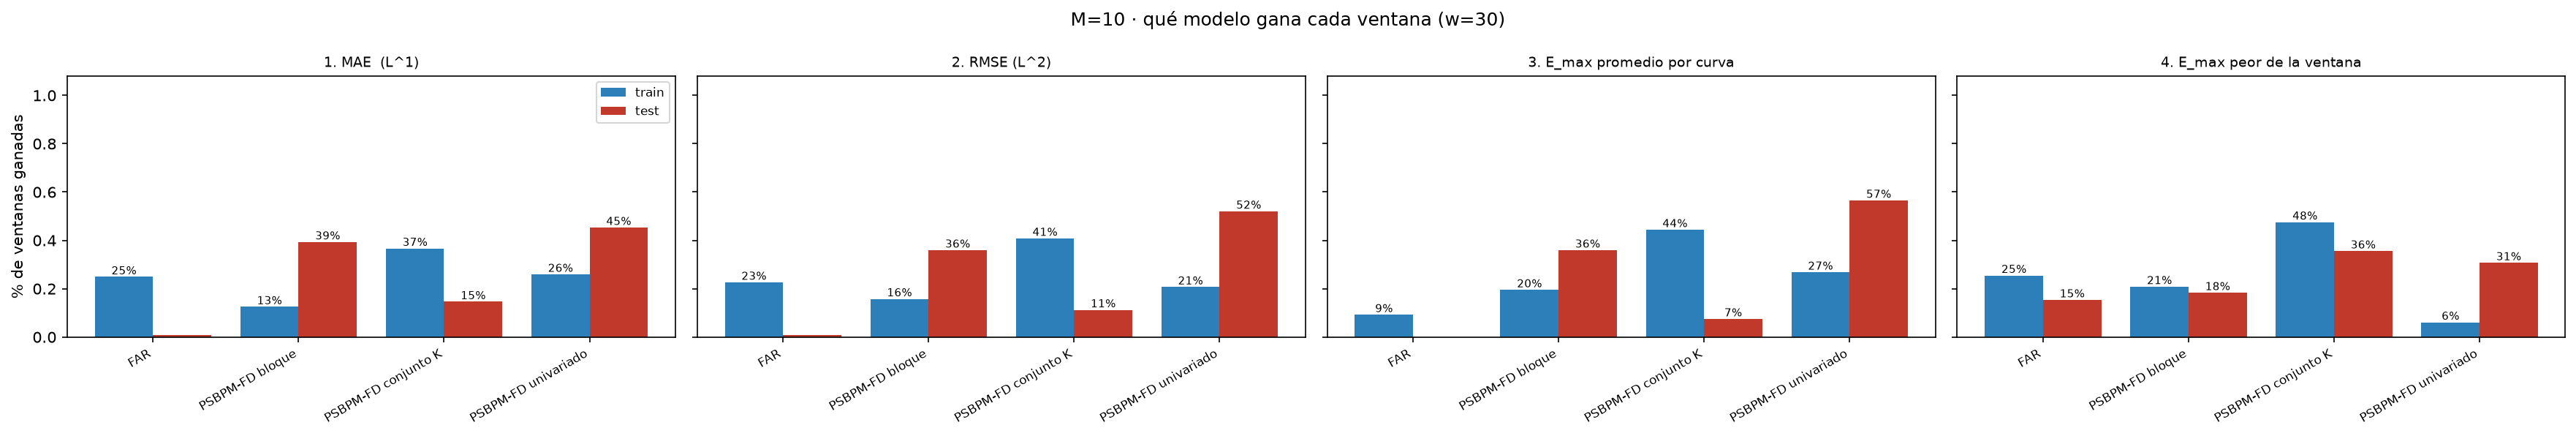

In [4]:
print("Bloque A (test): razón contra el FAR y contra el mejor, por métrica")
r = R["razones_A"]; display(r[r.bloque == "test"].round(3))
g = R["ganadores_A"]; display(g[g.bloque == "test"][["metrica", "modelo", "n_ventanas", "pct_ventanas_ganadas"]].round(3))
display(Image(filename=str(paths["out_report"] / "76_ganador_bloqueA.png")))

Bloque B (test): bandas


,metrica,bloque,banda,razon_vs_mejor,razon_vs_FAR
4,5. MPIW,test,FAR (IC gaussiano),1.004,1.000
5,5. MPIW,test,PSBPM-FD bloque (predictiva nativa),1.010,1.007
6,5. MPIW,test,PSBPM-FD conjunto K (predictiva nativa),1.023,1.019
7,5. MPIW,test,PSBPM-FD univariado (predictiva nativa),1.018,1.015
12,6. PICP puntual,test,FAR (IC gaussiano),2.018,1.000
13,6. PICP puntual,test,PSBPM-FD bloque (predictiva nativa),1.793,0.922
14,6. PICP puntual,test,PSBPM-FD conjunto K (predictiva nativa),1.732,1.007
15,6. PICP puntual,test,PSBPM-FD univariado (predictiva nativa),1.664,0.878
20,7. PICPB curva completa,test,FAR (IC gaussiano),1.127,1.000
21,7. PICPB curva completa,test,PSBPM-FD bloque (predictiva nativa),1.085,0.980


,metrica,banda,pct_ventanas_ganadas
4,5. MPIW,FAR (IC gaussiano),0.592
5,5. MPIW,PSBPM-FD bloque (predictiva nativa),0.326
6,5. MPIW,PSBPM-FD conjunto K (predictiva nativa),0.000
7,5. MPIW,PSBPM-FD univariado (predictiva nativa),0.082
12,6. PICP puntual,FAR (IC gaussiano),0.094
13,6. PICP puntual,PSBPM-FD bloque (predictiva nativa),0.187
14,6. PICP puntual,PSBPM-FD conjunto K (predictiva nativa),0.266
15,6. PICP puntual,PSBPM-FD univariado (predictiva nativa),0.453
20,7. PICPB curva completa,FAR (IC gaussiano),0.457
21,7. PICPB curva completa,PSBPM-FD bloque (predictiva nativa),0.311


,metrica,columna,banda,bloque,minimo,maximo,promedio
0,5. MPIW,mpiw,FAR (IC gaussiano),test,3.4363,3.4363,3.4363
2,5. MPIW,mpiw,PSBPM-FD bloque (predictiva nativa),test,3.3763,3.6035,3.4592
4,5. MPIW,mpiw,PSBPM-FD conjunto K (predictiva nativa),test,3.4874,3.5219,3.5011
6,5. MPIW,mpiw,PSBPM-FD univariado (predictiva nativa),test,3.3744,3.6631,3.4863
8,6. PICP puntual,picp,FAR (IC gaussiano),test,0.8671,0.9924,0.9433
10,6. PICP puntual,picp,PSBPM-FD bloque (predictiva nativa),test,0.8702,0.9911,0.9456
12,6. PICP puntual,picp,PSBPM-FD conjunto K (predictiva nativa),test,0.8707,0.9911,0.9465
14,6. PICP puntual,picp,PSBPM-FD univariado (predictiva nativa),test,0.8889,0.9929,0.9474
16,7. PICPB curva completa,picp_simultaneo,FAR (IC gaussiano),test,0.3000,0.9000,0.6413
18,7. PICPB curva completa,picp_simultaneo,PSBPM-FD bloque (predictiva nativa),test,0.4000,0.9000,0.6499


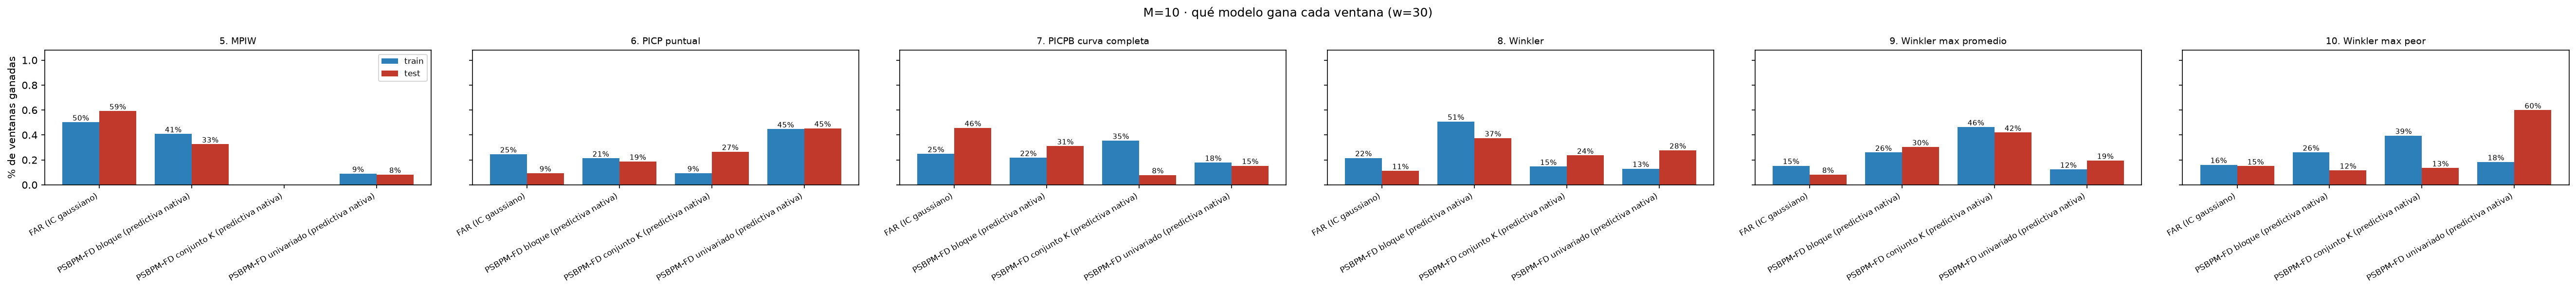

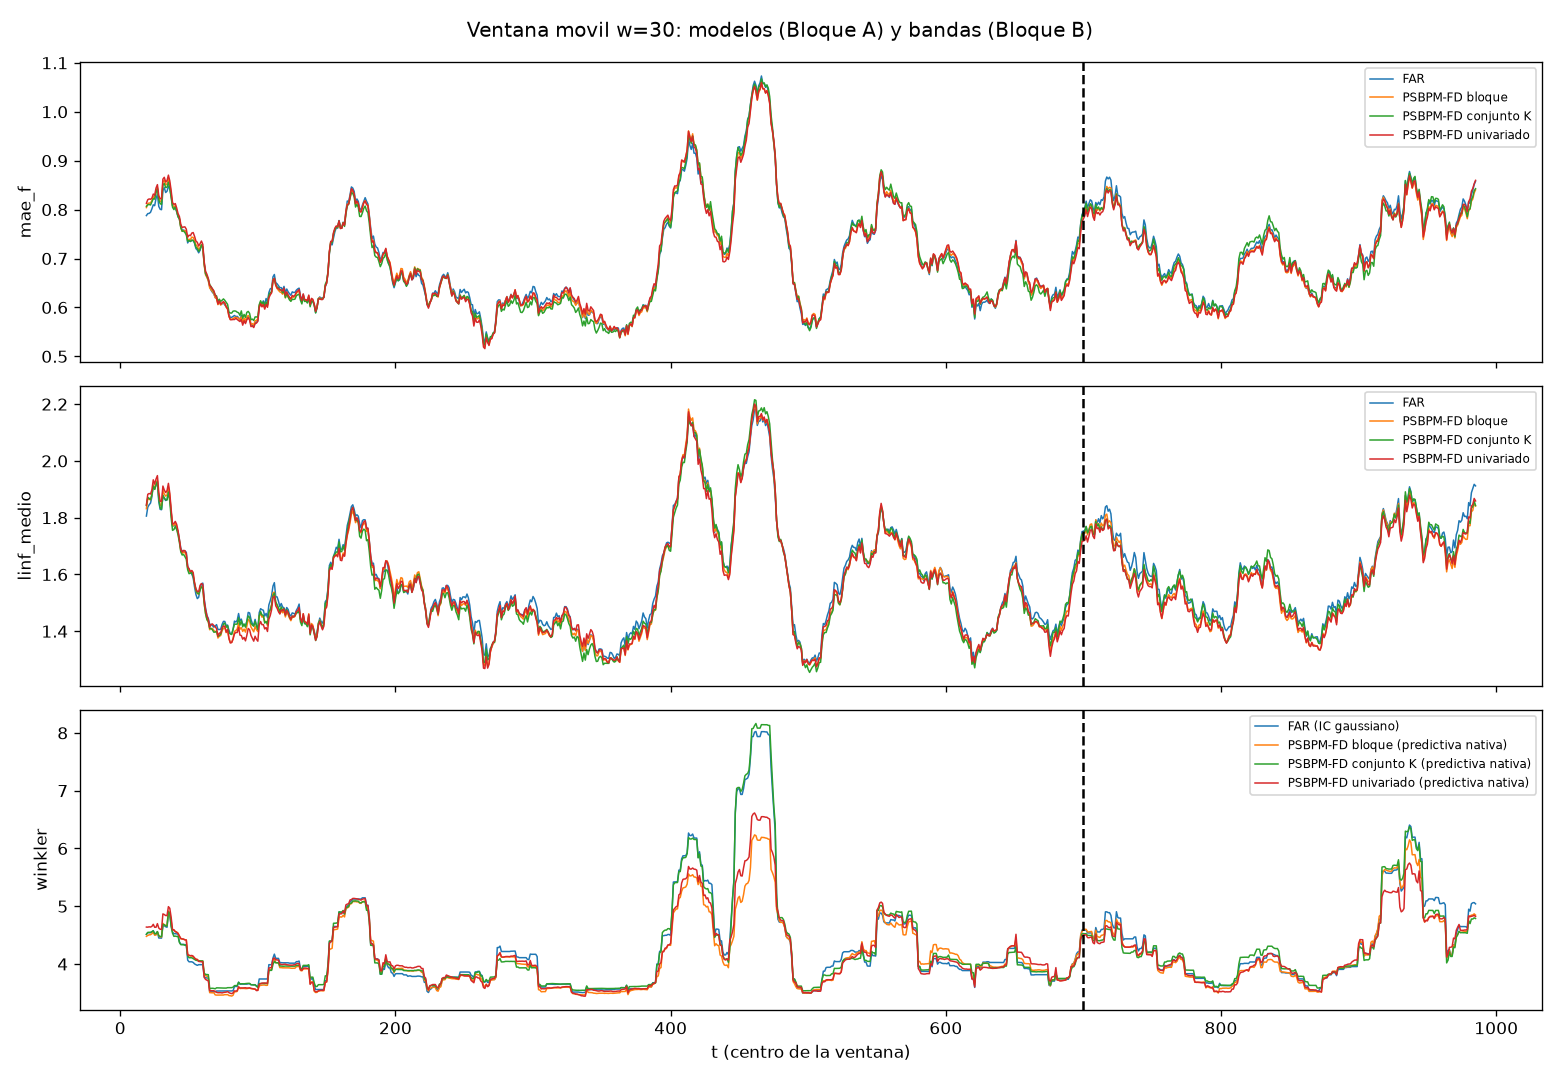

In [5]:
print("Bloque B (test): bandas")
rb = R["razones_B"]; display(rb[rb.bloque == "test"].round(3))
gb = R["ganadores_B"]; display(gb[gb.bloque == "test"][["metrica", "banda", "pct_ventanas_ganadas"]].round(3))
display(pd.read_csv(paths["out_report"] / "99_resumen_bloqueB_min_max_prom.csv").query("bloque == 'test'").round(4))
display(Image(filename=str(paths["out_report"] / "77_ganador_bloqueB.png")))
display(Image(filename=str(paths["out_report"] / "75_ventana_modelos_bandas.png")))